<a href="https://colab.research.google.com/github/fartech00/01/blob/main/NLP_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# https://drive.google.com/file/d/1fpRg9BDFTtZyoGqaljMI4NVuHmJU_Df_/view?usp=sharing

In [1]:
!pip install -q gdown


In [2]:

import gdown
import zipfile
import os

# ---------------- GOOGLE DRIVE LINK ----------------
url = "https://drive.google.com/file/d/1fpRg9BDFTtZyoGqaljMI4NVuHmJU_Df_/view?usp=sharing"

# ---------------- OUTPUT FILE ----------------
zip_file = "/content/dataset.zip"

# ---------------- EXTRACT FOLDER ----------------
extract_folder = "/content/dataset"

# ---------------- DOWNLOAD ----------------
gdown.download(
    url=url,
    output=zip_file,
    quiet=False,
    fuzzy=True
)

# ---------------- CREATE FOLDER ----------------
os.makedirs(extract_folder, exist_ok=True)

# ---------------- UNZIP ----------------
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("✅ Dataset yuklandi")

# ---------------- SHOW FILES ----------------
for root, dirs, files in os.walk(extract_folder):
    print(f"{root} --> {len(files)} files")

Downloading...
From: https://drive.google.com/uc?id=1fpRg9BDFTtZyoGqaljMI4NVuHmJU_Df_
To: /content/dataset.zip
100%|██████████| 450k/450k [00:00<00:00, 27.1MB/s]

✅ Dataset yuklandi
/content/dataset --> 0 files
/content/dataset/data --> 2 files
/content/dataset/data/debate --> 6 files


# NLP Processing and Sentiment Analysis on Debate Data


1. Loading raw text files
2. Building a structured dataframe
3. Exploratory data analysis
4. Text cleaning
5. Tokenization
6. Stopword removal
7. Stemming
8. Lemmatization
9. Sentiment analysis
10. Topic modeling with LDA
11. Interactive LDA visualization with `pyLDAvis`


In [3]:

import importlib.util
import subprocess
import sys

required_packages = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'sklearn': 'scikit-learn',
    'nltk': 'nltk',
    'wordcloud': 'wordcloud',
    'textblob': 'textblob',
    'pyLDAvis': 'pyLDAvis',
}

missing = [pip_name for import_name, pip_name in required_packages.items()
           if importlib.util.find_spec(import_name) is None]

if missing:
    print('Installing missing packages:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
else:
    print('All required packages are already installed.')

Installing missing packages: ['pyLDAvis']


In [4]:
import os
import re
import string
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

DATA_DIR = Path('/content/dataset/data/debate')
print('Data directory exists:', DATA_DIR.exists())
print('Files:', sorted(p.name for p in DATA_DIR.glob('*.txt')))

Data directory exists: True
Files: ['clinton_1st.txt', 'clinton_2nd.txt', 'clinton_3rd.txt', 'trump_1st.txt', 'trump_2nd.txt', 'trump_3rd.txt']


| Paketlar                          | Maqsadi                               |
| -------------------------------- | ------------------------------------- |
| `punkt`                          | Gap va so'zlar:  TOKENIZATION         |
| `punkt_tab`                      | Qo'shimcha tokenizer tables/models         |
| `stopwords`                      | Stop word-lar uchun “the”, “is”, “and”  |
| `wordnet`                        | Inglish tili sinonimlari uchun |
| `omw-1.4`                        | Ko'p tillarni mapping qilish uchun: WordNet          |
| `averaged_perceptron_tagger`     | POS                 |
| `averaged_perceptron_tagger_eng` | English POS modeli             |
| `vader_lexicon`                  | Sentiment analysis lug'ati (matnlardagi hissiy holatni aniqlash uchun ishlatiladigan lug‘at va qoidalar to‘plamidir)         |


In [5]:

import nltk

for package in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4', 'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng', 'vader_lexicon']:
    try:
        nltk.download(package, quiet=True)
    except Exception as exc:
        print(f'Could not download {package}: {exc}')

## 1. Dataset ni yuklash - Debate


In [6]:
def parse_file_metadata(path):
    stem = path.stem
    speaker, debate_label = stem.split('_', 1)
    debate_number = int(re.search(r'\d+', debate_label).group())
    return speaker.title(), debate_number

records = []
for path in sorted(DATA_DIR.glob('*.txt')):
    speaker, debate_number = parse_file_metadata(path)
    text = path.read_text(encoding='utf-8', errors='ignore').strip()
    records.append({
        'file': path.name,
        'speaker': speaker,
        'debate': debate_number,
        'raw_text': text,
        'characters': len(text),
        'raw_words': len(text.split())
    })

files_df = pd.DataFrame(records).sort_values(['debate', 'speaker']).reset_index(drop=True)
files_df

,file,speaker,debate,raw_text,characters,raw_words
0,clinton_1st.txt,Clinton,1,"How are you, Donald? Well, thank you, Lester, ...",34899,6382
1,trump_1st.txt,Trump,1,"Thank you, Lester. Our jobs are fleeing the co...",46296,8650
2,clinton_2nd.txt,Clinton,2,"Well, thank you. Are you a teacher? Yes, I thi...",33998,6272
3,trump_2nd.txt,Trump,2,"Well, I actually agree with that. I agree with...",39831,7334
4,clinton_3rd.txt,Clinton,3,"Thank you very much, Chris. And thanks to UNLV...",38302,6923
5,trump_3rd.txt,Trump,3,"Well, first of all, it's great to be with you,...",35597,6685


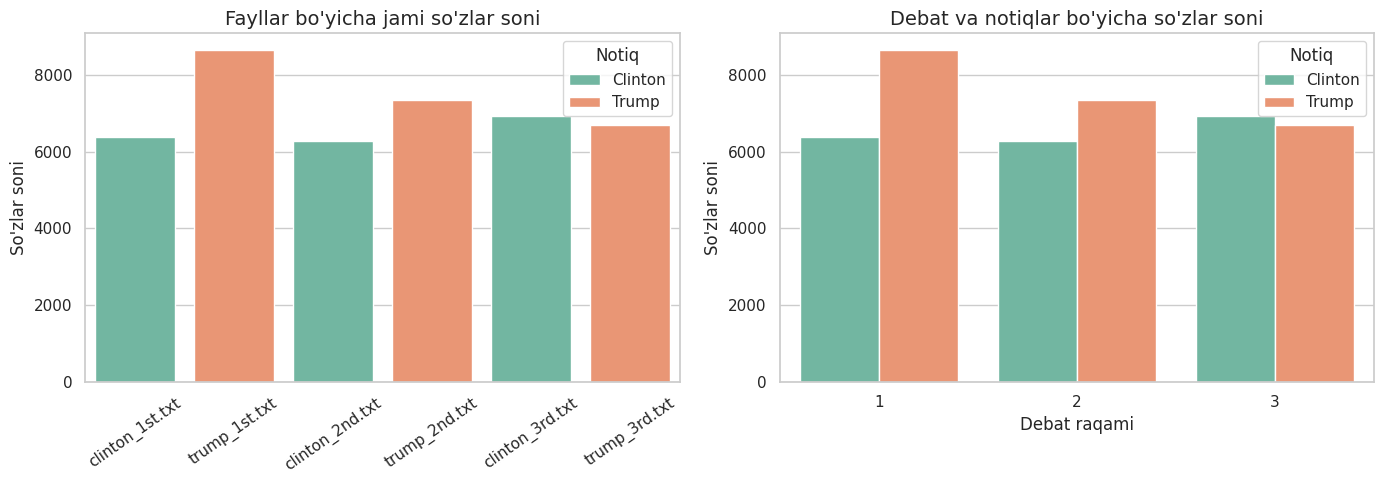

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1-grafik: Har bir fayldagi so'zlar soni
sns.barplot(data=files_df, x='file', y='raw_words', hue='speaker', ax=axes[0])
axes[0].set_title('Fayllar bo\'yicha jami so\'zlar soni')
axes[0].tick_params(axis='x', rotation=35)
axes[0].set_xlabel('')
axes[0].set_ylabel('So\'zlar soni')

# 2-grafik: Debat va notiqlar bo'yicha so'zlar soni
sns.barplot(data=files_df, x='debate', y='raw_words', hue='speaker', ax=axes[1])
axes[1].set_title('Debat va notiqlar bo\'yicha so\'zlar soni')
axes[1].set_xlabel('Debat raqami')
axes[1].set_ylabel('So\'zlar soni')

# Grafikdagi "speaker" yozuvini "Notiq"ga o'zgartirish (legend sarlavhasi)
axes[0].legend(title='Notiq')
axes[1].legend(title='Notiq')

plt.tight_layout()


## 2. Gaplar bo'yicha guruhlab olish -> har bir gap uchun alohida malumotlar bazasini (DataFrame) yaratish


In [8]:
from nltk.tokenize import sent_tokenize


def safe_sent_tokenize(text):
    try:
        return sent_tokenize(text)
    except LookupError:
        return re.split(r'(?<=[.!?])\s+', text)

sentence_records = []
for _, row in files_df.iterrows():
    sentences = [s.strip() for s in safe_sent_tokenize(row['raw_text']) if s.strip()]
    for i, sentence in enumerate(sentences, start=1):
        sentence_records.append({
            'file': row['file'],
            'speaker': row['speaker'],
            'debate': row['debate'],
            'sentence_id': i,
            'text': sentence,
            'char_len': len(sentence),
            'word_len': len(sentence.split())
        })

df = pd.DataFrame(sentence_records)
print(df.shape)
df.head(10)

(3148, 7)


,file,speaker,debate,sentence_id,text,char_len,word_len
0,clinton_1st.txt,Clinton,1,1,"How are you, Donald?",20,4
1,clinton_1st.txt,Clinton,1,2,"Well, thank you, Lester, and thanks to Hofstra...",62,11
2,clinton_1st.txt,Clinton,1,3,The central question in this election is reall...,128,24
3,clinton_1st.txt,Clinton,1,4,"Today is my granddaughter's second birthday, s...",73,13
4,clinton_1st.txt,Clinton,1,5,"First, we have to build an economy that works ...",86,17
5,clinton_1st.txt,Clinton,1,6,"That means we need new jobs, good jobs, with r...",60,11
6,clinton_1st.txt,Clinton,1,7,I want us to invest in you.,27,7
7,clinton_1st.txt,Clinton,1,8,I want us to invest in your future.,35,8
8,clinton_1st.txt,Clinton,1,9,"That means jobs in infrastructure, in advanced...",193,28
9,clinton_1st.txt,Clinton,1,10,We also have to make the economy fairer.,40,8


gaplar_soni  ortacha_sozlar  jami_sozlar
speaker debate                                          
Clinton 1               404           15.80         6382
        2               350           17.92         6272
        3               413           16.76         6923
Trump   1               732           11.82         8650
        2               643           11.41         7334
        3               606           11.03         6685

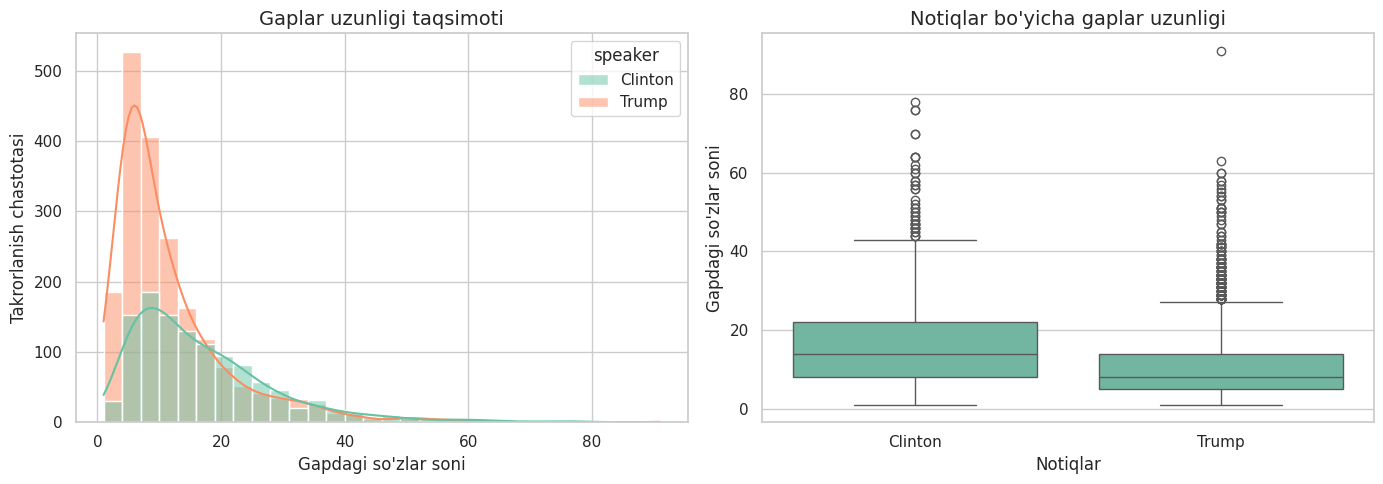

In [9]:
# Guruhlangan statistikani ko'rsatish:
# Bu jadval qaysi notiq ko'proq gapirgani va kim qisqaroq yoki uzunroq gaplarni afzal ko'rishini ko'rsatadi.
summary_df = df.groupby(['speaker', 'debate']).agg(
    gaplar_soni=('text', 'count'),
    ortacha_sozlar=('word_len', 'mean'),
    jami_sozlar=('word_len', 'sum')
).round(2)
display(summary_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1-Grafik: Gaplar uzunligi taqsimoti (Gistogramma)
sns.histplot(data=df, x='word_len', hue='speaker', bins=30, kde=True, ax=axes[0])
axes[0].set_title('Gaplar uzunligi taqsimoti')
axes[0].set_xlabel('Gapdagi so\'zlar soni')
axes[0].set_ylabel('Takrorlanish chastotasi')

# 2-Grafik: Notiqlar bo'yicha gaplar uzunligi (Boxplot)
sns.boxplot(data=df, x='speaker', y='word_len', ax=axes[1])
axes[1].set_title('Notiqlar bo\'yicha gaplar uzunligi')
axes[1].set_xlabel('Notiqlar')
axes[1].set_ylabel('Gapdagi so\'zlar soni')

plt.tight_layout()


## 3. Text Cleaning

- lowercasing
- removing URLs and HTML-like fragments
- expanding a few common contractions
- removing punctuation and digits
- normalizing whitespace

In [10]:
# Inglizcha qisqartmalar lug'ati
CONTRACTIONS = {
    "can't": 'cannot', "won't": 'will not', "n't": ' not', "'re": ' are',
    "'s": ' is', "'d": ' would', "'ll": ' will', "'t": ' not',
    "'ve": ' have', "'m": ' am'
}

def expand_contractions(text):
    """Qisqartmalarni to'liq shaklga keltirish"""
    for old, new in CONTRACTIONS.items():
        text = text.replace(old, new)
    return text

def clean_text(text):
    """Matnni tozalash: kichik harfga o'tkazish, belgilarni o'chirish"""
    text = text.lower() # Hammasini kichik harfga o'tkazish
    text = expand_contractions(text) # Qisqartmalarni ochish
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text) # Linklarni o'chirish
    text = re.sub(r'<.*?>', ' ', text) # HTML teglarni o'chirish
    text = re.sub(r'[^a-z\s]', ' ', text) # Faqat harflarni qoldirish
    text = re.sub(r'\s+', ' ', text).strip() # Ortiqcha bo'shliqlarni tozalash
    return text

# Tozalangan matn uchun yangi ustun yaratish
df['clean_text'] = df['text'].apply(clean_text)
display(df[['text', 'clean_text']].head(10))


,text,clean_text
0,"How are you, Donald?",how are you donald
1,"Well, thank you, Lester, and thanks to Hofstra...",well thank you lester and thanks to hofstra fo...
2,The central question in this election is reall...,the central question in this election is reall...
3,"Today is my granddaughter's second birthday, s...",today is my granddaughter is second birthday s...
4,"First, we have to build an economy that works ...",first we have to build an economy that works f...
5,"That means we need new jobs, good jobs, with r...",that means we need new jobs good jobs with ris...
6,I want us to invest in you.,i want us to invest in you
7,I want us to invest in your future.,i want us to invest in your future
8,"That means jobs in infrastructure, in advanced...",that means jobs in infrastructure in advanced ...
9,We also have to make the economy fairer.,we also have to make the economy fairer


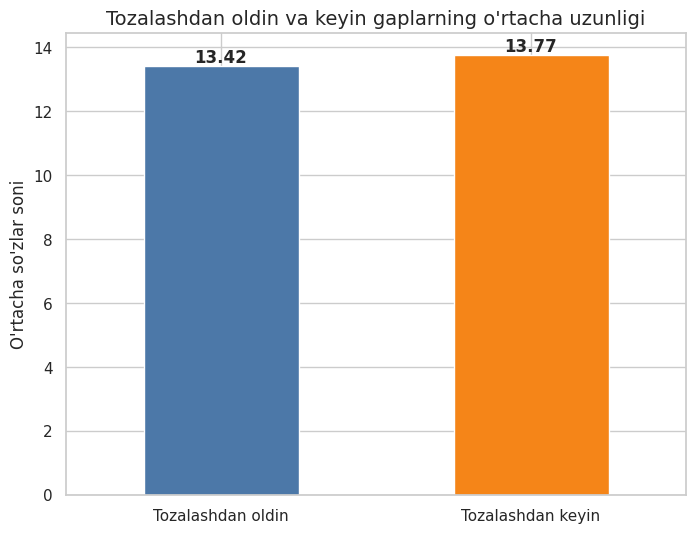

In [11]:
# Tozalangan matndagi so'zlar sonini hisoblash
df['clean_word_len'] = df['clean_text'].str.split().str.len()

# Tozalashdan oldingi va keyingi o'rtacha uzunlikni solishtirish
length_compare = df[['word_len', 'clean_word_len']].mean().rename({
    'word_len': 'Tozalashdan oldin',
    'clean_word_len': 'Tozalashdan keyin'
})

# Grafikni chizish
plt.figure(figsize=(8, 6))
ax = length_compare.plot(kind='bar', color=['#4C78A8', '#F58518'])
ax.set_title('Tozalashdan oldin va keyin gaplarning o\'rtacha uzunligi')
ax.set_ylabel('O\'rtacha so\'zlar soni')
ax.set_xticklabels(length_compare.index, rotation=0)

# Ustunlar ustiga qiymatlarni yozib qo'yish (aniqroq ko'rinishi uchun)
for i, v in enumerate(length_compare):
    ax.text(i, v + 0.1, str(round(v, 2)), ha='center', fontweight='bold')

plt.show()


## 4. Tokenization


In [12]:
from nltk.tokenize import word_tokenize


def safe_word_tokenize(text):
    try:
        return word_tokenize(text)
    except LookupError:
        return re.findall(r'[a-z]+', text)

df['tokens'] = df['clean_text'].apply(safe_word_tokenize)
df[['clean_text', 'tokens']].head(10)

,clean_text,tokens
0,how are you donald,"[how, are, you, donald]"
1,well thank you lester and thanks to hofstra fo...,"[well, thank, you, lester, and, thanks, to, ho..."
2,the central question in this election is reall...,"[the, central, question, in, this, election, i..."
3,today is my granddaughter is second birthday s...,"[today, is, my, granddaughter, is, second, bir..."
4,first we have to build an economy that works f...,"[first, we, have, to, build, an, economy, that..."
5,that means we need new jobs good jobs with ris...,"[that, means, we, need, new, jobs, good, jobs,..."
6,i want us to invest in you,"[i, want, us, to, invest, in, you]"
7,i want us to invest in your future,"[i, want, us, to, invest, in, your, future]"
8,that means jobs in infrastructure in advanced ...,"[that, means, jobs, in, infrastructure, in, ad..."
9,we also have to make the economy fairer,"[we, also, have, to, make, the, economy, fairer]"


In [13]:
# Barcha tokenlarni bitta ro'yxatga yig'ish
all_tokens = [token for tokens in df['tokens'] for token in tokens]

print(f"Jami so'zlar (tokenlar) soni: {len(all_tokens)}")
print(f"Unikal (takrorlanmas) so'zlar soni: {len(set(all_tokens))}")
print(f"Leksik boylik ko'rsatkichi (TTR): {len(set(all_tokens)) / len(all_tokens):.4f}")
print("-" * 30)
print("Dastlabki 30 ta so'z namunasi:")
print(all_tokens[:30])


Jami so'zlar (tokenlar) soni: 43405
Unikal (takrorlanmas) so'zlar soni: 3228
Leksik boylik ko'rsatkichi (TTR): 0.0744
------------------------------
Dastlabki 30 ta so'z namunasi:
['how', 'are', 'you', 'donald', 'well', 'thank', 'you', 'lester', 'and', 'thanks', 'to', 'hofstra', 'for', 'hosting', 'us', 'the', 'central', 'question', 'in', 'this', 'election', 'is', 'really', 'what', 'kind', 'of', 'country', 'we', 'want', 'to']


## 5. Stopword Removal


In [14]:
from nltk.corpus import stopwords

try:
    stop_words = set(stopwords.words('english'))
except LookupError:
    stop_words = {'the', 'and', 'is', 'in', 'to', 'of', 'a', 'for', 'on', 'that', 'this', 'we', 'it', 'are'}

# Debate transcripts contain many candidate/moderator references that can dominate topic words.
custom_stopwords = {
    'donald', 'trump', 'hillary', 'clinton', 'secretary', 'lester', 'well',
    'would', 'could', 'also', 'said', 'say', 'one', 'think', 'know', 'going'
}
stop_words = stop_words.union(custom_stopwords)

def remove_stopwords(tokens):
    return [token for token in tokens if token not in stop_words and len(token) > 2]

df['tokens_no_stop'] = df['tokens'].apply(remove_stopwords)
df[['tokens', 'tokens_no_stop']].head(10)

,tokens,tokens_no_stop
0,"[how, are, you, donald]",[]
1,"[well, thank, you, lester, and, thanks, to, ho...","[thank, thanks, hofstra, hosting]"
2,"[the, central, question, in, this, election, i...","[central, question, election, really, kind, co..."
3,"[today, is, my, granddaughter, is, second, bir...","[today, granddaughter, second, birthday, lot]"
4,"[first, we, have, to, build, an, economy, that...","[first, build, economy, works, everyone, top]"
5,"[that, means, we, need, new, jobs, good, jobs,...","[means, need, new, jobs, good, jobs, rising, i..."
6,"[i, want, us, to, invest, in, you]","[want, invest]"
7,"[i, want, us, to, invest, in, your, future]","[want, invest, future]"
8,"[that, means, jobs, in, infrastructure, in, ad...","[means, jobs, infrastructure, advanced, manufa..."
9,"[we, also, have, to, make, the, economy, fairer]","[make, economy, fairer]"


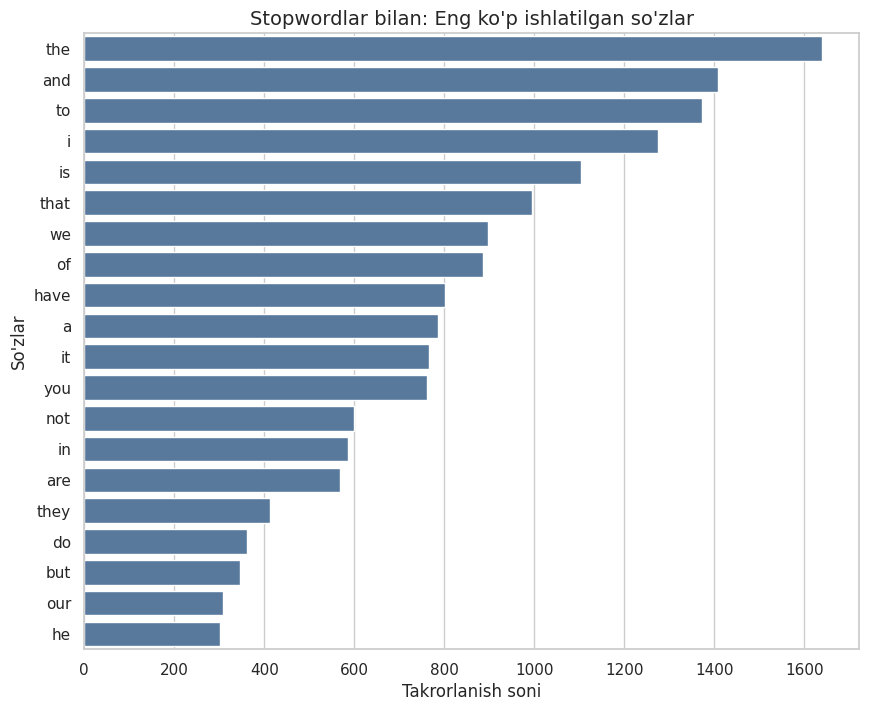

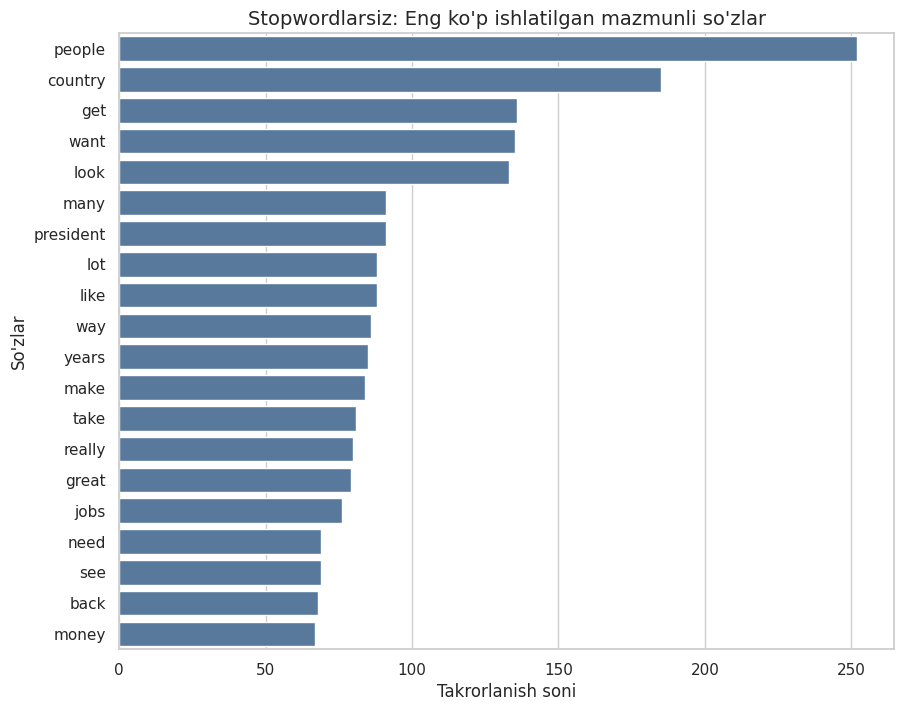

In [15]:
from collections import Counter

def plot_top_words(tokens, title, n=20):
    # Eng ko'p ishlatilgan so'zlarni sanash
    counts = Counter(tokens).most_common(n)
    plot_df = pd.DataFrame(counts, columns=['so\'z', 'soni'])

    plt.figure(figsize=(10, 8))
    ax = sns.barplot(data=plot_df, y='so\'z', x='soni', color='#4C78A8')

    # Sarlavhalarni o'zbekcha qilish
    ax.set_title(title)
    ax.set_xlabel('Takrorlanish soni')
    ax.set_ylabel('So\'zlar')
    plt.show()

# 1. Stopwordlar bilan birga (umumiy holat)
plot_top_words(all_tokens, 'Stopwordlar bilan: Eng ko\'p ishlatilgan so\'zlar')

# 2. Stopwordlarsiz (mazmunli so'zlar)
all_tokens_no_stop = [token for tokens in df['tokens_no_stop'] for token in tokens]
plot_top_words(all_tokens_no_stop, 'Stopwordlarsiz: Eng ko\'p ishlatilgan mazmunli so\'zlar')


## 6. Stemming


In [16]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
df['stemmed_tokens'] = df['tokens_no_stop'].apply(lambda tokens: [stemmer.stem(token) for token in tokens])
df[['tokens_no_stop', 'stemmed_tokens']].head(10)

,tokens_no_stop,stemmed_tokens
0,[],[]
1,"[thank, thanks, hofstra, hosting]","[thank, thank, hofstra, host]"
2,"[central, question, election, really, kind, co...","[central, question, elect, realli, kind, count..."
3,"[today, granddaughter, second, birthday, lot]","[today, granddaught, second, birthday, lot]"
4,"[first, build, economy, works, everyone, top]","[first, build, economi, work, everyon, top]"
5,"[means, need, new, jobs, good, jobs, rising, i...","[mean, need, new, job, good, job, rise, incom]"
6,"[want, invest]","[want, invest]"
7,"[want, invest, future]","[want, invest, futur]"
8,"[means, jobs, infrastructure, advanced, manufa...","[mean, job, infrastructur, advanc, manufactur,..."
9,"[make, economy, fairer]","[make, economi, fairer]"


## 7. Lemmatization


In [17]:
from nltk import pos_tag
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()


def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    if treebank_tag.startswith('V'):
        return wordnet.VERB
    if treebank_tag.startswith('N'):
        return wordnet.NOUN
    if treebank_tag.startswith('R'):
        return wordnet.ADV
    return wordnet.NOUN


def lemmatize_tokens(tokens):
    try:
        tagged = pos_tag(tokens)
        return [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in tagged]
    except LookupError:
        return [lemmatizer.lemmatize(word) for word in tokens]

df['lemma_tokens'] = df['tokens_no_stop'].apply(lemmatize_tokens)
df['processed_text'] = df['lemma_tokens'].apply(lambda tokens: ' '.join(tokens))
df[['tokens_no_stop', 'stemmed_tokens', 'lemma_tokens', 'processed_text']].head(10)

,tokens_no_stop,stemmed_tokens,lemma_tokens,processed_text
0,[],[],[],
1,"[thank, thanks, hofstra, hosting]","[thank, thank, hofstra, host]","[thank, thanks, hofstra, host]",thank thanks hofstra host
2,"[central, question, election, really, kind, co...","[central, question, elect, realli, kind, count...","[central, question, election, really, kind, co...",central question election really kind country ...
3,"[today, granddaughter, second, birthday, lot]","[today, granddaught, second, birthday, lot]","[today, granddaughter, second, birthday, lot]",today granddaughter second birthday lot
4,"[first, build, economy, works, everyone, top]","[first, build, economi, work, everyon, top]","[first, build, economy, work, everyone, top]",first build economy work everyone top
5,"[means, need, new, jobs, good, jobs, rising, i...","[mean, need, new, job, good, job, rise, incom]","[mean, need, new, job, good, job, rise, income]",mean need new job good job rise income
6,"[want, invest]","[want, invest]","[want, invest]",want invest
7,"[want, invest, future]","[want, invest, futur]","[want, invest, future]",want invest future
8,"[means, jobs, infrastructure, advanced, manufa...","[mean, job, infrastructur, advanc, manufactur,...","[mean, job, infrastructure, advance, manufactu...",mean job infrastructure advance manufacture in...
9,"[make, economy, fairer]","[make, economi, fairer]","[make, economy, fairer]",make economy fairer


In [18]:
sample_idx = df['tokens_no_stop'].str.len().sort_values(ascending=False).index[0]
comparison = pd.DataFrame({
    'original_token': df.loc[sample_idx, 'tokens_no_stop'][:25],
    'stemmed': df.loc[sample_idx, 'stemmed_tokens'][:25],
    'lemmatized': df.loc[sample_idx, 'lemma_tokens'][:25]
})
comparison

,original_token,stemmed,lemmatized
0,watch,watch,watch
1,deals,deal,deal
2,made,made,make
3,watch,watch,watch
4,happening,happen,happen
5,horrible,horribl,horrible
6,things,thing,thing
7,like,like,like
8,obamacare,obamacar,obamacare
9,health,health,health


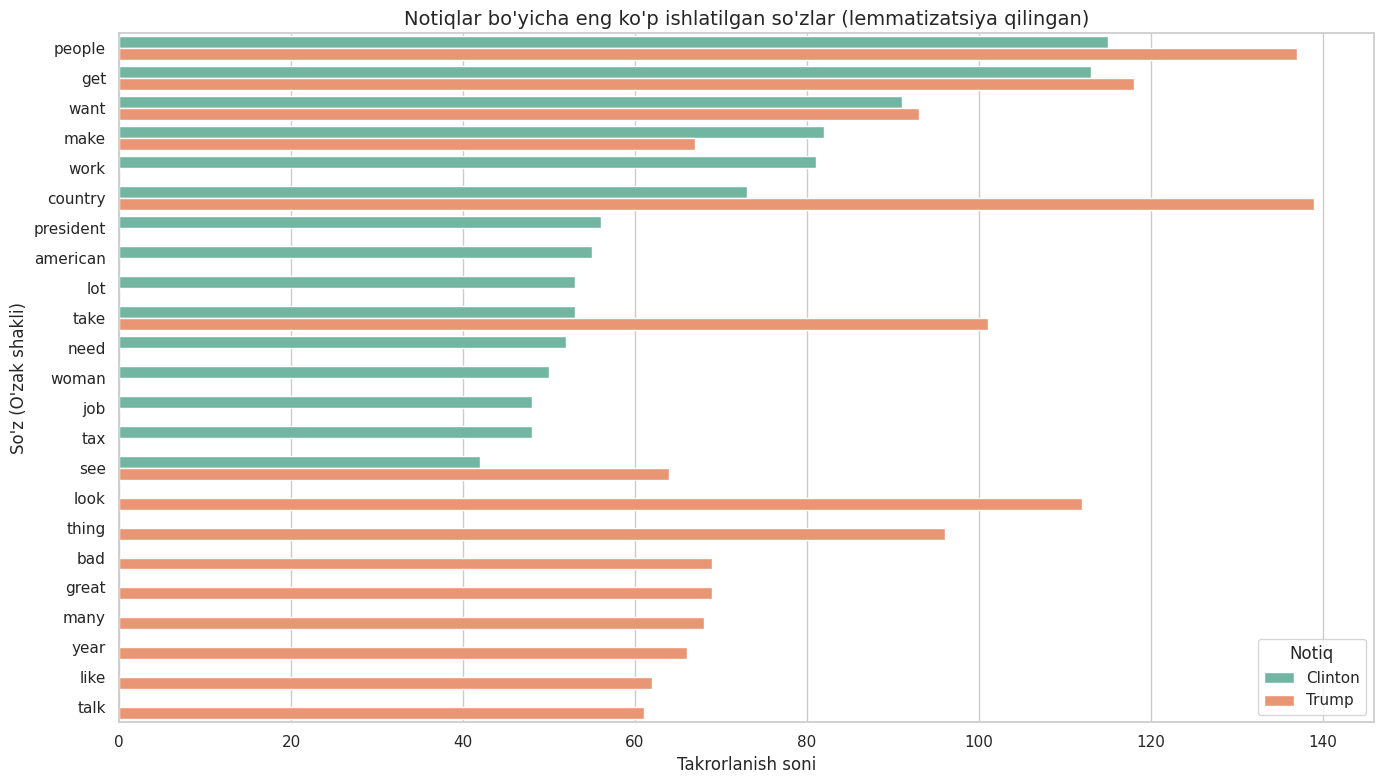

In [19]:
# Har bir notiq bo'yicha so'zlarni guruhlash va sanash
speaker_words = (
    df.explode('lemma_tokens')
      .dropna(subset=['lemma_tokens'])
      .query('lemma_tokens != ""')
      .groupby(['speaker', 'lemma_tokens'])
      .size()
      .reset_index(name='count')
)

# Har bir notiq uchun eng ko'p ishlatilgan top 15 ta so'zni olish
top_by_speaker = speaker_words.sort_values(['speaker', 'count'], ascending=[True, False]).groupby('speaker').head(15)

plt.figure(figsize=(14, 8))
# Grafikni chizish
ax = sns.barplot(data=top_by_speaker, y='lemma_tokens', x='count', hue='speaker')

# Sarlavhalarni o'zbekcha qilish
plt.title('Notiqlar bo\'yicha eng ko\'p ishlatilgan so\'zlar (lemmatizatsiya qilingan)')
plt.xlabel('Takrorlanish soni')
plt.ylabel('So\'z (O\'zak shakli)')
plt.legend(title='Notiq')

plt.tight_layout()
plt.show()


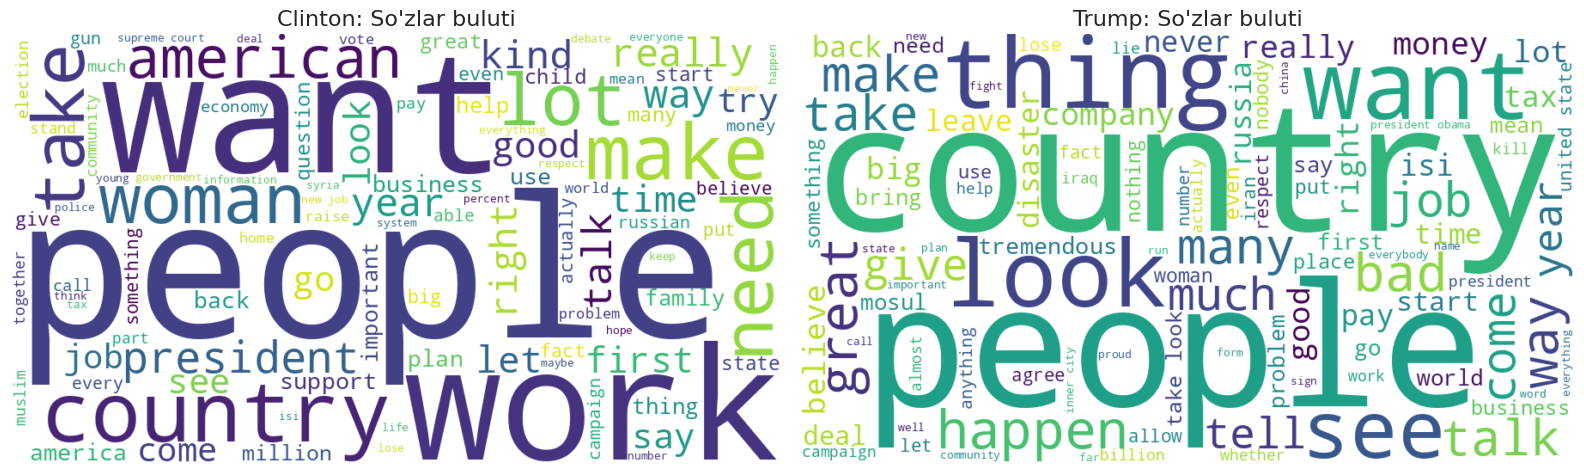

In [20]:
try:
    from wordcloud import WordCloud

    # Notiqlar ro'yxatini olish
    unique_speakers = sorted(df['speaker'].unique())
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    for ax, speaker in zip(axes, unique_speakers):
        # Har bir notiq uchun matnlarni birlashtirish
        text = ' '.join(df.loc[df['speaker'] == speaker, 'processed_text'])

        # WordCloud parametrlarini sozlash
        wc = WordCloud(
            width=900,
            height=500,
            background_color='white',
            colormap='viridis',
            max_words=100  # Eng muhim 100 ta so'z
        ).generate(text)

        # Grafikni ko'rsatish
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f'{speaker}: So\'zlar buluti', fontsize=16)
        ax.axis('off') # O'qlarni yashirish

    plt.tight_layout()
    plt.show()
except ImportError:
    print('Xatolik: wordcloud kutubxonasi o\'rnatilmagan.')


## 8. Sentiment Analysis



In [21]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

sentiment_scores = df['text'].apply(sia.polarity_scores).apply(pd.Series)
df = pd.concat([df, sentiment_scores], axis=1)

def sentiment_label(compound):
    if compound >= 0.05:
        return 'positive'
    if compound <= -0.05:
        return 'negative'
    return 'neutral'

df['sentiment'] = df['compound'].apply(sentiment_label)
df[['speaker', 'debate', 'text', 'neg', 'neu', 'pos', 'compound', 'sentiment']].head(20)

,speaker,debate,text,neg,neu,pos,compound,sentiment
0,Clinton,1,"How are you, Donald?",0.000,1.000,0.000,0.0000,neutral
1,Clinton,1,"Well, thank you, Lester, and thanks to Hofstra...",0.000,0.516,0.484,0.7579,positive
2,Clinton,1,The central question in this election is reall...,0.000,0.947,0.053,0.0772,positive
3,Clinton,1,"Today is my granddaughter's second birthday, s...",0.000,1.000,0.000,0.0000,neutral
4,Clinton,1,"First, we have to build an economy that works ...",0.000,0.899,0.101,0.2023,positive
5,Clinton,1,"That means we need new jobs, good jobs, with r...",0.000,0.775,0.225,0.4404,positive
6,Clinton,1,I want us to invest in you.,0.000,0.794,0.206,0.0772,positive
7,Clinton,1,I want us to invest in your future.,0.000,0.822,0.178,0.0772,positive
8,Clinton,1,"That means jobs in infrastructure, in advanced...",0.000,0.719,0.281,0.8126,positive
9,Clinton,1,We also have to make the economy fairer.,0.000,1.000,0.000,0.0000,neutral


In [22]:
sentiment_summary = df.groupby(['speaker', 'debate']).agg(
    sentences=('text', 'count'),
    avg_compound=('compound', 'mean'),
    positive_share=('sentiment', lambda x: (x == 'positive').mean()),
    neutral_share=('sentiment', lambda x: (x == 'neutral').mean()),
    negative_share=('sentiment', lambda x: (x == 'negative').mean())
).round(3)

sentiment_summary

sentences  avg_compound  positive_share  neutral_share  \
speaker debate                                                           
Clinton 1             404         0.054           0.413          0.309   
        2             350         0.110           0.431          0.334   
        3             413         0.057           0.380          0.346   
Trump   1             732         0.026           0.311          0.449   
        2             643         0.014           0.330          0.386   
        3             606        -0.003           0.266          0.469   

                negative_share  
speaker debate                  
Clinton 1                0.277  
        2                0.234  
        3                0.274  
Trump   1                0.239  
        2                0.285  
        3                0.266

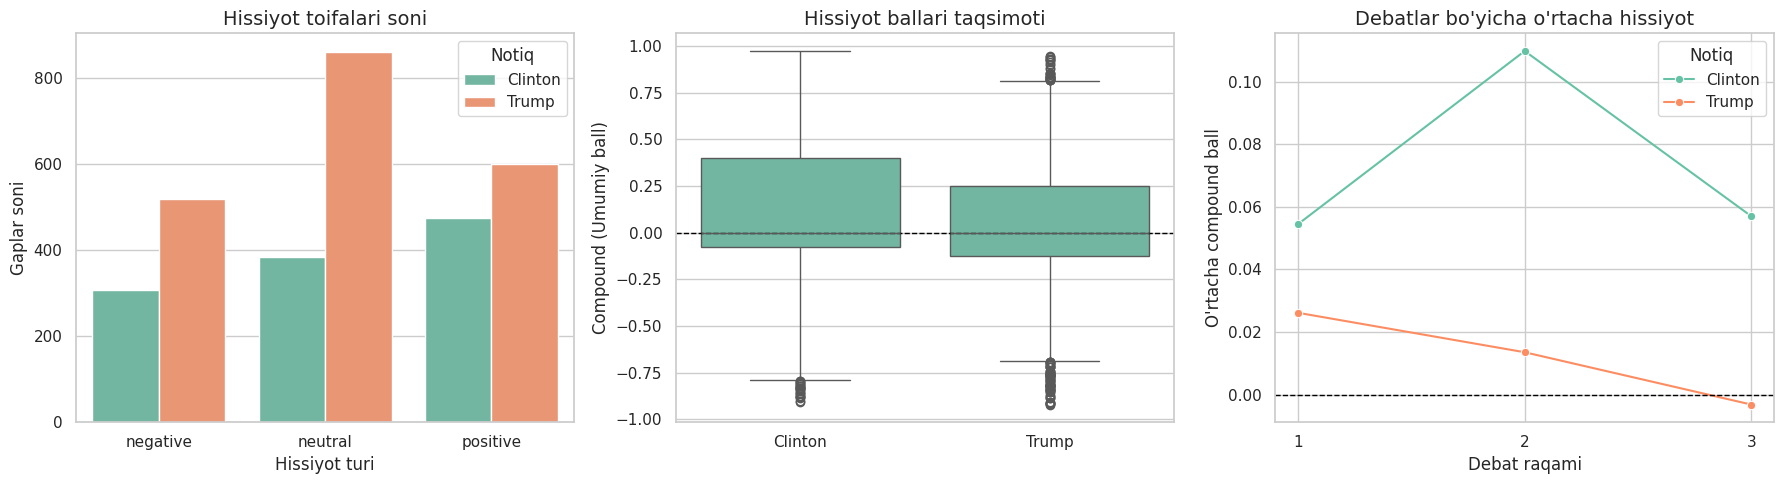

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1-Grafik: Hissiyot toifalari soni
sns.countplot(data=df, x='sentiment', hue='speaker', order=['negative', 'neutral', 'positive'], ax=axes[0])
axes[0].set_title('Hissiyot toifalari soni')
axes[0].set_xlabel('Hissiyot turi')
axes[0].set_ylabel('Gaplar soni')
axes[0].legend(title='Notiq')

# 2-Grafik: Hissiyot ballari taqsimoti (Boxplot)
sns.boxplot(data=df, x='speaker', y='compound', ax=axes[1])
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_title('Hissiyot ballari taqsimoti')
axes[1].set_xlabel('')
axes[1].set_ylabel('Compound (Umumiy ball)')

# 3-Grafik: Debatlar davomida hissiyot o'zgarishi (Lineplot)
avg_sentiment = df.groupby(['speaker', 'debate'], as_index=False)['compound'].mean()
sns.lineplot(data=avg_sentiment, x='debate', y='compound', hue='speaker', marker='o', ax=axes[2])
axes[2].axhline(0, color='black', linewidth=1, linestyle='--')
axes[2].set_title('Debatlar bo\'yicha o\'rtacha hissiyot')
axes[2].set_xlabel('Debat raqami')
axes[2].set_ylabel('O\'rtacha compound ball')
axes[2].set_xticks(sorted(df['debate'].unique()))
axes[2].legend(title='Notiq')

plt.tight_layout()
plt.show()


In [24]:
# Eng ijobiy gaplarni chiqarish
print('--- Eng ijobiy (pozitiv) gaplar ---')
display(df.sort_values('compound', ascending=False)[['speaker', 'debate', 'compound', 'text']].head(10))

print('\n' + '='*50 + '\n')

# Eng salbiy gaplarni chiqarish
print('--- Eng salbiy (negativ) gaplar ---')
display(df.sort_values('compound')[['speaker', 'debate', 'compound', 'text']].head(10))


--- Eng ijobiy (pozitiv) gaplar ---


,speaker,debate,compound,text
1166,Clinton,2,0.9732,That's why -- to go back to your question -- I...
2243,Clinton,3,0.9722,It's pretty clear you won't admit... ... that ...
2384,Clinton,3,0.9642,"But I am happy, in fact I'm thrilled to talk a..."
106,Clinton,1,0.9559,But it's because I see this -- we need to have...
859,Trump,1,0.9455,"In Palm Beach, Florida, tough community, a bri..."
2889,Trump,3,0.9428,"The other things are false, but honestly, I'd ..."
1786,Trump,2,0.9386,"I have a very, very great balance sheet, so gr..."
2738,Trump,3,0.9288,"But I'd like to start off where we left, becau..."
193,Clinton,1,0.9287,We have to work to make sure that our police a...
1510,Trump,2,0.9282,But I want to do things that haven't been done...




--- Eng salbiy (negativ) gaplar ---


,speaker,debate,compound,text
2592,Trump,3,-0.9217,"In the audience tonight, we have four mothers ..."
778,Trump,1,-0.9186,I think maybe there's a political reason why y...
1519,Trump,2,-0.9166,"You know, when we have a world where you have ..."
723,Trump,1,-0.9136,"In a place like Chicago, where thousands of pe..."
2887,Trump,3,-0.9117,So sad when she talks about violence at my ral...
3053,Trump,3,-0.9111,"But if they ever did overthrow Assad, you migh..."
2863,Trump,3,-0.9100,"And I'll tell you what, in particular in Chica..."
1266,Clinton,2,-0.9081,There are children suffering in this catastrop...
44,Clinton,1,-0.9001,"We had the worst financial crisis, the Great R..."
1098,Trump,1,-0.8885,"But it's bad, bad experience."


In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Kerakli resurslarni yuklash
nltk.download('vader_lexicon')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt')

sia = SentimentIntensityAnalyzer()

def analyze_text(text):
    # 1. VADER Sentiment (Hissiyot)
    sentiment_score = sia.polarity_scores(text)['compound']

    # 2. POS Tagging (Sifatlar sonini aniqlash - notiqning tasvirlash qobiliyati)
    tokens = nltk.word_tokenize(text)
    tags = nltk.pos_tag(tokens)
    # JJ - sifat (adjective), notiqning matni qanchalik rang-barangligini ko'rsatadi
    adj_count = len([word for word, tag in tags if tag == 'JJ'])

    # 3. Leksik boylik (Unikal so'zlar nisbati)
    words = text.lower().split()
    lexical_diversity = len(set(words)) / len(words) if len(words) > 0 else 0

    return sentiment_score, adj_count, lexical_diversity

# DataFrame-ni yangi ma'lumotlar bilan to'ldiramiz
analysis_results = files_df['raw_text'].apply(analyze_text)
files_df[['sentiment', 'adj_count', 'lexical_richness']] = pd.DataFrame(analysis_results.tolist(), index=files_df.index)


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


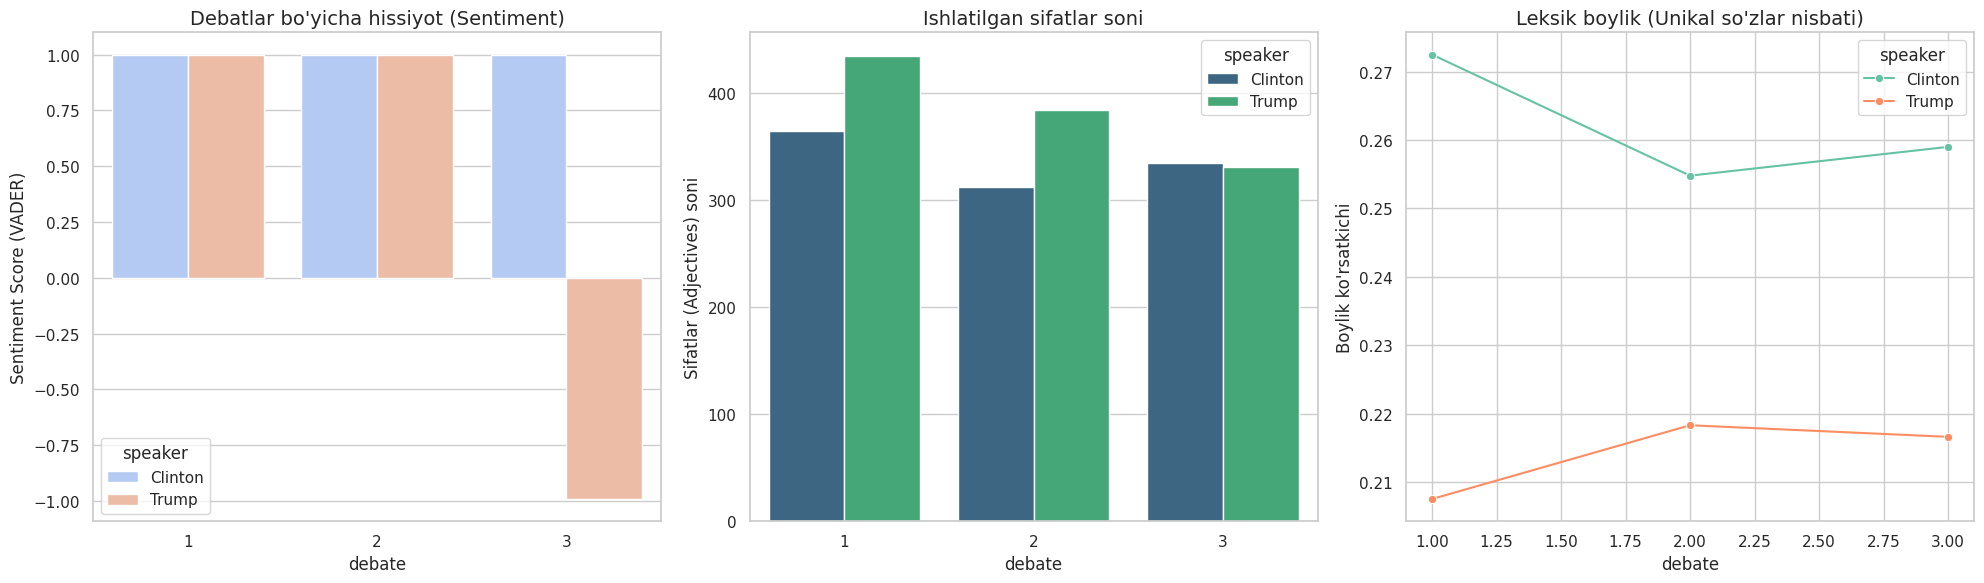

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1-Grafik: Hissiyot tahlili (Sentiment)
sns.barplot(data=files_df, x='debate', y='sentiment', hue='speaker', ax=axes[0], palette='coolwarm')
axes[0].set_title('Debatlar bo\'yicha hissiyot (Sentiment)')
axes[0].set_ylabel('Sentiment Score (VADER)')

# 2-Grafik: Sifatlar soni (Adjectives count) - Notiqning so'z boyligi ifodasi
sns.barplot(data=files_df, x='debate', y='adj_count', hue='speaker', ax=axes[1], palette='viridis')
axes[1].set_title('Ishlatilgan sifatlar soni')
axes[1].set_ylabel('Sifatlar (Adjectives) soni')

# 3-Grafik: Leksik boylik (Lexical Richness)
sns.lineplot(data=files_df, x='debate', y='lexical_richness', hue='speaker', marker='o', ax=axes[2])
axes[2].set_title('Leksik boylik (Unikal so\'zlar nisbati)')
axes[2].set_ylabel('Boylik ko\'rsatkichi')

plt.tight_layout()
plt.show()


In [27]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# VADER yuklash
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

# DataFrame yaratilgandan so'ng tahlil qilish
def get_sentiment(text):
    return sia.polarity_scores(text)['compound']

# Yangi ustun qo'shish
files_df['sentiment'] = files_df['raw_text'].apply(get_sentiment)

# Natijani ko'rish
print(files_df[['speaker', 'debate', 'sentiment']].head())


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


   speaker  debate  sentiment
0  Clinton       1     0.9996
1    Trump       1     0.9999
2  Clinton       2     0.9999
3    Trump       2     0.9991
4  Clinton       3     0.9998


## 9. Feature Extraction for Topic Modeling



In [28]:
from sklearn.feature_extraction.text import CountVectorizer

# Kamida 4 ta mazmunli so'zi bor gaplarni saralab olish
topic_df = df[df['processed_text'].str.split().str.len() >= 4].copy().reset_index(drop=True)

# Vektorizatorni sozlash
vectorizer = CountVectorizer(
    max_df=0.85, # O'ta ko'p uchraydigan so'zlarni tashlab yuborish
    min_df=2,    # Kam uchraydigan so'zlarni tashlab yuborish
    max_features=1000,
    ngram_range=(1, 2) # Birikmalarni ham hisobga olish
)

# Matrisani yaratish
dtm = vectorizer.fit_transform(topic_df['processed_text'])
feature_names = vectorizer.get_feature_names_out()

print(f"Mavzu tahlili uchun tanlangan gaplar soni: {topic_df.shape[0]}")
print(f"Matritsa o'lchami (Gaplar x So'zlar): {dtm.shape}")
print("-" * 30)
print("Dastlabki 20 ta kalit so'z va birikmalar:")
print(feature_names[:20])


Mavzu tahlili uchun tanlangan gaplar soni: 1684
Matritsa o'lchami (Gaplar x So'zlar): (1684, 1000)
------------------------------
Dastlabki 20 ta kalit so'z va birikmalar:
['able' 'abortion' 'abraham' 'abraham lincoln' 'abroad' 'absolutely'
 'account' 'across' 'act' 'action' 'actually' 'ad' 'add' 'add trillion'
 'administration' 'admiral' 'advantage' 'advocate' 'afford' 'affordable']


## 10. LDA Topic Modeling



In [29]:
from sklearn.decomposition import LatentDirichletAllocation

# LDA modelini sozlash va o'rgatish
N_TOPICS = 5
lda_model = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    learning_method='batch',
    max_iter=20
)

# Matrisani modelga berish
doc_topic = lda_model.fit_transform(dtm)

def show_topics(model, feature_names, n_words=12):
    rows = []
    for topic_idx, topic in enumerate(model.components_):
        # Eng muhim so'zlarning indekslarini topish
        top_indices = topic.argsort()[:-n_words - 1:-1]
        top_words = [feature_names[i] for i in top_indices]
        rows.append({
            'Mavzu raqami': topic_idx + 1,
            'Asosiy kalit so\'zlar': ', '.join(top_words)
        })
    return pd.DataFrame(rows)

# Natijani jadval ko'rinishida ko'rish
topics_summary = show_topics(lda_model, feature_names, n_words=12)
display(topics_summary)


,Mavzu raqami,Asosiy kalit so'zlar
0,1,"take, people, time, make, nuclear, get, countr..."
1,2,"get, people, new, bad, million, job, want, mak..."
2,3,"woman, year, tax, really, want, plan, thing, c..."
3,4,"state, look, back, want, great, put, united, m..."
4,5,"american, country, need, let, look, work, lot,..."


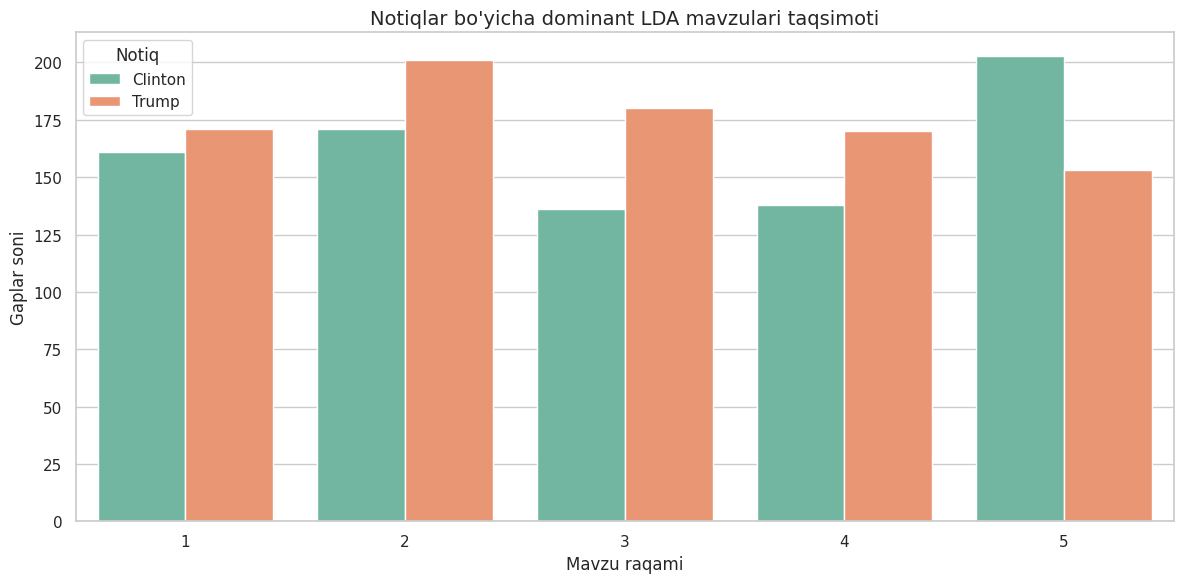

In [30]:
# Har bir gap uchun eng yuqori ehtimollikka ega mavzuni aniqlash
topic_df['dominant_topic'] = doc_topic.argmax(axis=1) + 1
topic_df['topic_probability'] = doc_topic.max(axis=1)

# Notiqlar va mavzular bo'yicha gaplar sonini hisoblash
topic_counts = topic_df.groupby(['speaker', 'dominant_topic']).size().reset_index(name='sentences')

plt.figure(figsize=(12, 6))
# Grafikni chizish
ax = sns.barplot(data=topic_counts, x='dominant_topic', y='sentences', hue='speaker')

# Sarlavhalarni o'zbekcha qilish
plt.title('Notiqlar bo\'yicha dominant LDA mavzulari taqsimoti')
plt.xlabel('Mavzu raqami')
plt.ylabel('Gaplar soni')
plt.legend(title='Notiq')

plt.tight_layout()
plt.show()


# Ushbu kod LDA tahlili natijalarini har bir notiq kesimida vizualizatsiya qiladi.
# Bu orqali qaysi notiq qaysi mavzuga (topic) ko‘proq urg‘u berganini
# va ularning debatdagi asosiy strategiyasini tushunish mumkin.

In [31]:
# Har bir mavzu bo'yicha statistikani hisoblash
topic_sentiment = topic_df.groupby('dominant_topic').agg(
    gaplar_soni=('text', 'count'),
    ortacha_hissiyot=('compound', 'mean'),
    misol_gap=('text', 'first')
).round(3)

# Natijani ko'rish
display(topic_sentiment)


,gaplar_soni,ortacha_hissiyot,misol_gap
dominant_topic,,,
1,332,0.064,"Well, thank you, Lester, and thanks to Hofstra..."
2,372,0.003,"That means jobs in infrastructure, in advanced..."
3,316,-0.006,The central question in this election is reall...
4,308,0.182,I also want to see more companies do profit-sh...
5,356,0.075,"Today is my granddaughter's second birthday, s..."


## 11. Interactive LDA Visualization with pyLDAvis



In [32]:
try:
    import pyLDAvis
    import pyLDAvis.lda_model

    # Notebook muhitida vizualizatsiyani yoqish
    pyLDAvis.enable_notebook()

    # LDA modelini vizualizatsiya uchun tayyorlash
    lda_vis = pyLDAvis.lda_model.prepare(lda_model, dtm, vectorizer, sort_topics=False)

    # Vizualizatsiyani ko'rsatish
    display(lda_vis)

except ImportError:
    print('Xatolik: pyLDAvis o\'rnatilmagan. O\'rnatish uchun: %pip install pyLDAvis')
except Exception as exc:
    print('Vizualizatsiya yaratishda xatolik yuz berdi:', exc)


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.186884 -0.074621       1        1  20.316177
1      0.041670 -0.097008       2        1  23.897762
2     -0.196376 -0.116220       3        1  17.302757
3     -0.026727  0.153494       4        1  18.476319
4     -0.005451  0.134354       5        1  20.006985, topic_info=         Term        Freq       Total Category  logprob  loglift
859      take  118.000000  118.000000  Default  30.0000  30.0000
40   american   67.000000   67.000000  Default  29.0000  29.0000
835     state   64.000000   64.000000  Default  28.0000  28.0000
972     woman   55.000000   55.000000  Default  27.0000  27.0000
593      need   60.000000   60.000000  Default  26.0000  26.0000
..        ...         ...         ...      ...      ...      ...
645    people   21.932855  211.579940   Topic5  -4.7533  -0.6575
360      give   15.687768   51.938839   Topic5  -5.0884   0.4119
988      year   15.834526   81.467686   Topic5  -5.0791  -0.0289
125     bring   14.895077   37.079825   Topic5  -5.1403   0.6970
881     thing   15.403573   75.025745   Topic5  -5.1067   0.0259

[329 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
0         1  0.557394      able
0         2  0.445915      able
8         2  0.154091       act
8         4  0.847501       act
10        2  0.158501  actually
...     ...       ...       ...
988       4  0.073649      year
988       5  0.196397      year
989       3  0.915823  year ago
994       2  0.955662      york
998       2  0.879759      zero

[485 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Next

## 13. Experiment: Compare Different Numbers of LDA Topics


In [33]:
topic_numbers = [3, 4, 6, 8]
lda_results = []
lda_models = {}
lda_doc_topics = {}

for n_topics in topic_numbers:
    model = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        learning_method='batch',
        max_iter=20
    )
    matrix = model.fit_transform(dtm)
    lda_models[n_topics] = model
    lda_doc_topics[n_topics] = matrix
    lda_results.append({
        'n_topics': n_topics,
        'perplexity': model.perplexity(dtm),
        'log_likelihood': model.score(dtm)
    })

lda_compare_df = pd.DataFrame(lda_results)
lda_compare_df

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,n_topics,perplexity,log_likelihood
0,3,714.309297,-83541.141045
1,4,748.589614,-84137.061187
2,6,774.752805,-84573.792095
3,8,796.584137,-84927.070339


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


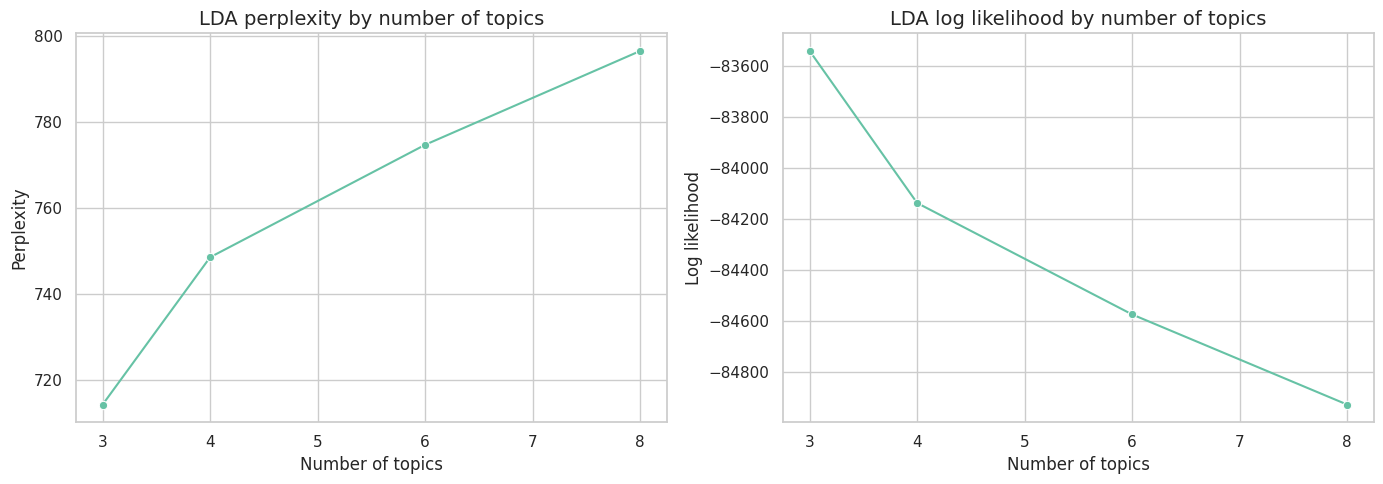

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=lda_compare_df, x='n_topics', y='perplexity', marker='o', ax=axes[0])
axes[0].set_title('LDA perplexity by number of topics')
axes[0].set_xlabel('Number of topics')
axes[0].set_ylabel('Perplexity')

sns.lineplot(data=lda_compare_df, x='n_topics', y='log_likelihood', marker='o', ax=axes[1])
axes[1].set_title('LDA log likelihood by number of topics')
axes[1].set_xlabel('Number of topics')
axes[1].set_ylabel('Log likelihood')

plt.tight_layout()

In [ ]:
all_topic_words = []
for n_topics, model in lda_models.items():
    topic_words = show_topics(model, feature_names, n_words=10)
    topic_words.insert(0, 'n_topics', n_topics)
    all_topic_words.append(topic_words)

all_topic_words_df = pd.concat(all_topic_words, ignore_index=True)
all_topic_words_df

,n_topics,Mavzu raqami,Asosiy kalit so'zlar
0,3,1,"take, people, lot, state, make, get, country, ..."
1,3,2,"people, get, many, see, country, bad, job, dea..."
2,3,3,"tax, want, country, get, make, year, woman, pl..."
3,4,1,"people, take, make, country, american, lot, nu..."
4,4,2,"get, people, bad, deal, new, obama, million, w..."
5,4,3,"country, want, woman, tax, plan, year, kind, f..."
6,4,4,"look, state, back, great, bring, company, unit..."
7,6,1,"take, people, nuclear, country, many, second, ..."
8,6,2,"people, get, deal, million, new, percent, coun..."
9,6,3,"year, want, tremendous, many, thing, border, d..."


In [ ]:
# Save separate LDAvis HTML files for each topic count.
# Open these files in your browser to compare topic separation interactively.
try:
    import pyLDAvis
    import pyLDAvis.lda_model

    lda_vis_paths = []
    for n_topics, model in lda_models.items():
        vis = pyLDAvis.lda_model.prepare(model, dtm, vectorizer, sort_topics=False)
        out_path = Path(f'/home/farhod/Desktop/TAFU/TAFU/code/ML/lda_debate_{n_topics}_topics.html')
        pyLDAvis.save_html(vis, str(out_path))
        lda_vis_paths.append(str(out_path))

    print('Saved LDAvis comparison files:')
    for p in lda_vis_paths:
        print(p)
except ImportError:
    print('pyLDAvis is not installed. Run the setup cell first.')
except Exception as exc:
    print('Could not save LDAvis comparison files:', exc)

Saved LDAvis comparison files:
/home/farhod/Desktop/TAFU/TAFU/code/ML/lda_debate_3_topics.html
/home/farhod/Desktop/TAFU/TAFU/code/ML/lda_debate_4_topics.html
/home/farhod/Desktop/TAFU/TAFU/code/ML/lda_debate_6_topics.html
/home/farhod/Desktop/TAFU/TAFU/code/ML/lda_debate_8_topics.html


## 14. Experiment: Paragraph-Level / Chunk-Level Topic Modeling

The original files are one long line, so true paragraph boundaries are not available. To create broader documents, we group every 5 consecutive sentences from the same speaker and debate into one chunk.

Sentence-level topics are detailed. Chunk-level topics are broader and often easier to interpret.

In [ ]:
CHUNK_SIZE = 5
chunk_records = []

for (speaker, debate, file_name), group in df.sort_values(['speaker', 'debate', 'sentence_id']).groupby(['speaker', 'debate', 'file']):
    sentences = group['text'].tolist()
    for start in range(0, len(sentences), CHUNK_SIZE):
        chunk_text = ' '.join(sentences[start:start + CHUNK_SIZE])
        chunk_records.append({
            'speaker': speaker,
            'debate': debate,
            'file': file_name,
            'chunk_id': start // CHUNK_SIZE + 1,
            'text': chunk_text,
            'sentence_count': len(sentences[start:start + CHUNK_SIZE])
        })

chunk_df = pd.DataFrame(chunk_records)
chunk_df['clean_text'] = chunk_df['text'].apply(clean_text)
chunk_df['tokens'] = chunk_df['clean_text'].apply(safe_word_tokenize)
chunk_df['tokens_no_stop'] = chunk_df['tokens'].apply(remove_stopwords)
chunk_df['lemma_tokens'] = chunk_df['tokens_no_stop'].apply(lemmatize_tokens)
chunk_df['processed_text'] = chunk_df['lemma_tokens'].apply(lambda tokens: ' '.join(tokens))

print(chunk_df.shape)
chunk_df.head()

(632, 11)


,speaker,debate,file,chunk_id,text,sentence_count,clean_text,tokens,tokens_no_stop,lemma_tokens,processed_text
0,Clinton,1,clinton_1st.txt,1,"How are you, Donald? Well, thank you, Lester, ...",5,how are you donald well thank you lester and t...,"[how, are, you, donald, well, thank, you, lest...","[thank, thanks, hofstra, hosting, central, que...","[thank, thanks, hofstra, host, central, questi...",thank thanks hofstra host central question ele...
1,Clinton,1,clinton_1st.txt,2,"That means we need new jobs, good jobs, with r...",5,that means we need new jobs good jobs with ris...,"[that, means, we, need, new, jobs, good, jobs,...","[means, need, new, jobs, good, jobs, rising, i...","[mean, need, new, job, good, job, rise, income...",mean need new job good job rise income want in...
2,Clinton,1,clinton_1st.txt,3,That starts with raising the national minimum ...,5,that starts with raising the national minimum ...,"[that, starts, with, raising, the, national, m...","[starts, raising, national, minimum, wage, gua...","[start, raise, national, minimum, wage, guaran...",start raise national minimum wage guarantee fi...
3,Clinton,1,clinton_1st.txt,4,"So let's have paid family leave, earned sick d...",5,so let is have paid family leave earned sick d...,"[so, let, is, have, paid, family, leave, earne...","[let, paid, family, leave, earned, sick, days,...","[let, pay, family, leave, earn, sick, day, let...",let pay family leave earn sick day let sure af...
4,Clinton,1,clinton_1st.txt,5,We're going to have a debate where we are talk...,5,we are going to have a debate where we are tal...,"[we, are, going, to, have, a, debate, where, w...","[debate, talking, important, issues, facing, c...","[debate, talk, important, issue, face, country...",debate talk important issue face country judge...


In [ ]:
chunk_vectorizer = CountVectorizer(
    max_df=0.90,
    min_df=2,
    max_features=1000,
    ngram_range=(1, 2)
)
chunk_dtm = chunk_vectorizer.fit_transform(chunk_df['processed_text'])
chunk_feature_names = chunk_vectorizer.get_feature_names_out()

chunk_lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42,
    learning_method='batch',
    max_iter=20
)
chunk_doc_topic = chunk_lda.fit_transform(chunk_dtm)
chunk_df['dominant_topic'] = chunk_doc_topic.argmax(axis=1) + 1
chunk_df['topic_probability'] = chunk_doc_topic.max(axis=1)

show_topics(chunk_lda, chunk_feature_names, n_words=12)

,Mavzu raqami,Asosiy kalit so'zlar
0,1,"country, people, woman, make, get, work, want,..."
1,2,"want, iran, russia, get, nuclear, deal, make, ..."
2,3,"people, take, look, country, get, back, want, ..."
3,4,"see, second, believe, people, gun, year, happe..."
4,5,"president, get, obama, talk, much, work, thing..."


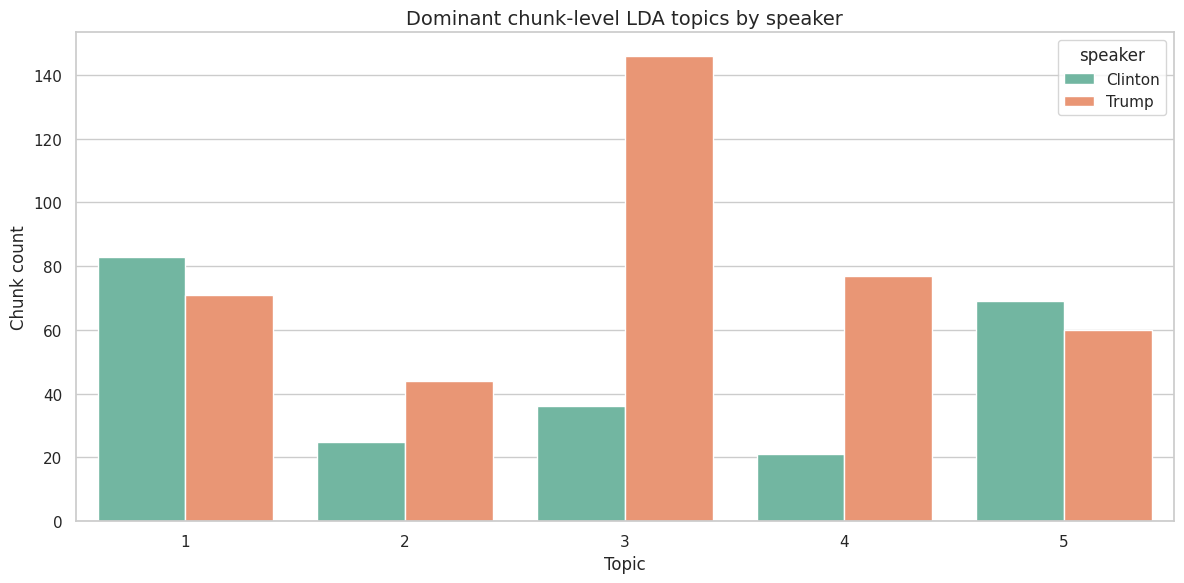

In [ ]:
chunk_topic_counts = chunk_df.groupby(['speaker', 'dominant_topic']).size().reset_index(name='chunks')

plt.figure(figsize=(12, 6))
sns.barplot(data=chunk_topic_counts, x='dominant_topic', y='chunks', hue='speaker')
plt.title('Dominant chunk-level LDA topics by speaker')
plt.xlabel('Topic')
plt.ylabel('Chunk count')
plt.tight_layout()

In [ ]:
try:
    import pyLDAvis
    import pyLDAvis.lda_model

    chunk_lda_vis = pyLDAvis.lda_model.prepare(chunk_lda, chunk_dtm, chunk_vectorizer, sort_topics=False)
    chunk_vis_path = Path('/home/farhod/Desktop/TAFU/TAFU/code/ML/lda_debate_chunk_level.html')
    pyLDAvis.save_html(chunk_lda_vis, str(chunk_vis_path))
    print('Saved chunk-level LDAvis HTML to:', chunk_vis_path)
    chunk_lda_vis
except ImportError:
    print('pyLDAvis is not installed. Run the setup cell first.')
except Exception as exc:
    print('Could not create chunk-level LDAvis:', exc)

Saved chunk-level LDAvis HTML to: /home/farhod/Desktop/TAFU/TAFU/code/ML/lda_debate_chunk_level.html


## 15. Experiment: Supervised Sentiment Classifier


1. Convert processed text into TF-IDF features
2. Split into train and test sets
3. Train a Logistic Regression classifier
4. Evaluate with accuracy, classification report, and confusion matrix

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

clf_df = df[df['processed_text'].str.len() > 0].copy()
X = clf_df['processed_text']
y = clf_df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

tfidf = TfidfVectorizer(max_features=2500, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

sentiment_clf = LogisticRegression(max_iter=1000, class_weight='balanced')
sentiment_clf.fit(X_train_tfidf, y_train)

y_pred = sentiment_clf.predict(X_test_tfidf)

print('Accuracy:', round(accuracy_score(y_test, y_pred), 3))
print(classification_report(y_test, y_pred))

Accuracy: 0.677
              precision    recall  f1-score   support

    negative       0.66      0.61      0.64       205
     neutral       0.66      0.75      0.70       293
    positive       0.71      0.65      0.68       267

    accuracy                           0.68       765
   macro avg       0.68      0.67      0.67       765
weighted avg       0.68      0.68      0.68       765



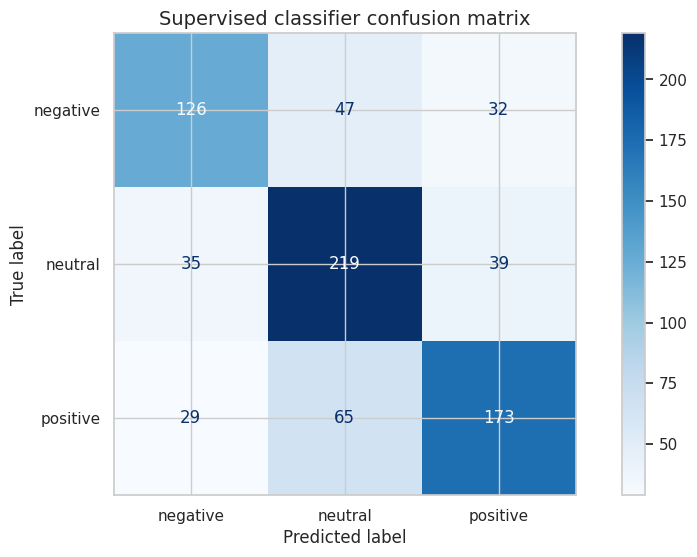

In [ ]:
labels = ['negative', 'neutral', 'positive']
cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', values_format='d')
plt.title('Supervised classifier confusion matrix')
plt.show()

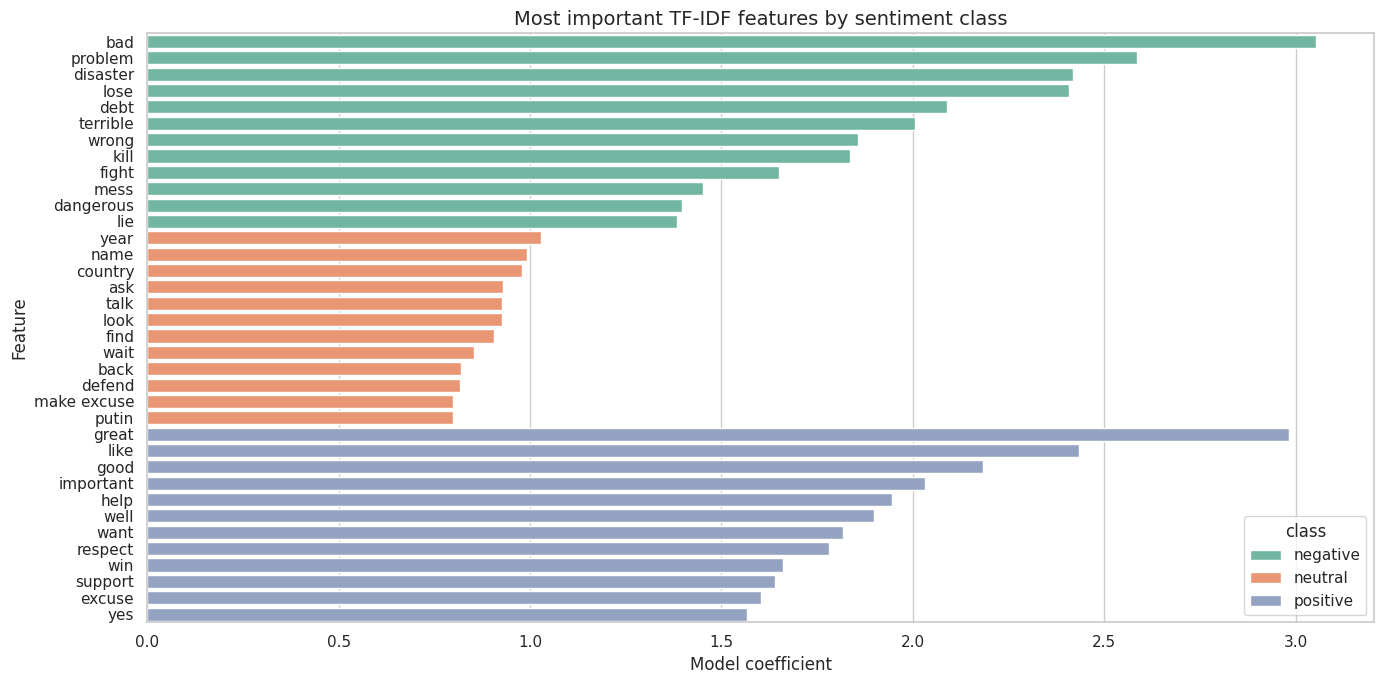

In [ ]:
feature_names_tfidf = np.array(tfidf.get_feature_names_out())
coef_df = []

for class_index, class_name in enumerate(sentiment_clf.classes_):
    top_positive = sentiment_clf.coef_[class_index].argsort()[-12:][::-1]
    coef_df.append(pd.DataFrame({
        'class': class_name,
        'feature': feature_names_tfidf[top_positive],
        'weight': sentiment_clf.coef_[class_index][top_positive]
    }))

coef_df = pd.concat(coef_df, ignore_index=True)

plt.figure(figsize=(14, 7))
sns.barplot(data=coef_df, x='weight', y='feature', hue='class')
plt.title('Most important TF-IDF features by sentiment class')
plt.xlabel('Model coefficient')
plt.ylabel('Feature')
plt.tight_layout()

## 16. Experiment: Compare VADER, TextBlob, and Transformer Sentiment

VADER is lexicon-based and works well as a lightweight baseline. TextBlob is another simple polarity method. Transformer sentiment models can be stronger, but they require larger packages and may need internet access the first time they download a model.

In [ ]:
try:
    from textblob import TextBlob

    df['textblob_polarity'] = df['text'].apply(lambda text: TextBlob(text).sentiment.polarity)
    df['textblob_subjectivity'] = df['text'].apply(lambda text: TextBlob(text).sentiment.subjectivity)

    def textblob_label(score):
        if score >= 0.05:
            return 'positive'
        if score <= -0.05:
            return 'negative'
        return 'neutral'

    df['textblob_sentiment'] = df['textblob_polarity'].apply(textblob_label)

    display(df[['speaker', 'debate', 'compound', 'sentiment', 'textblob_polarity', 'textblob_sentiment']].head())
except ImportError:
    print('TextBlob is not installed. Run the setup cell first.')

,speaker,debate,compound,sentiment,textblob_polarity,textblob_sentiment
0,Clinton,1,0.0000,neutral,0.000,neutral
1,Clinton,1,0.7579,positive,0.200,positive
2,Clinton,1,0.0772,positive,0.280,positive
3,Clinton,1,0.0000,neutral,0.000,neutral
4,Clinton,1,0.2023,positive,0.375,positive


Correlation: 0.502


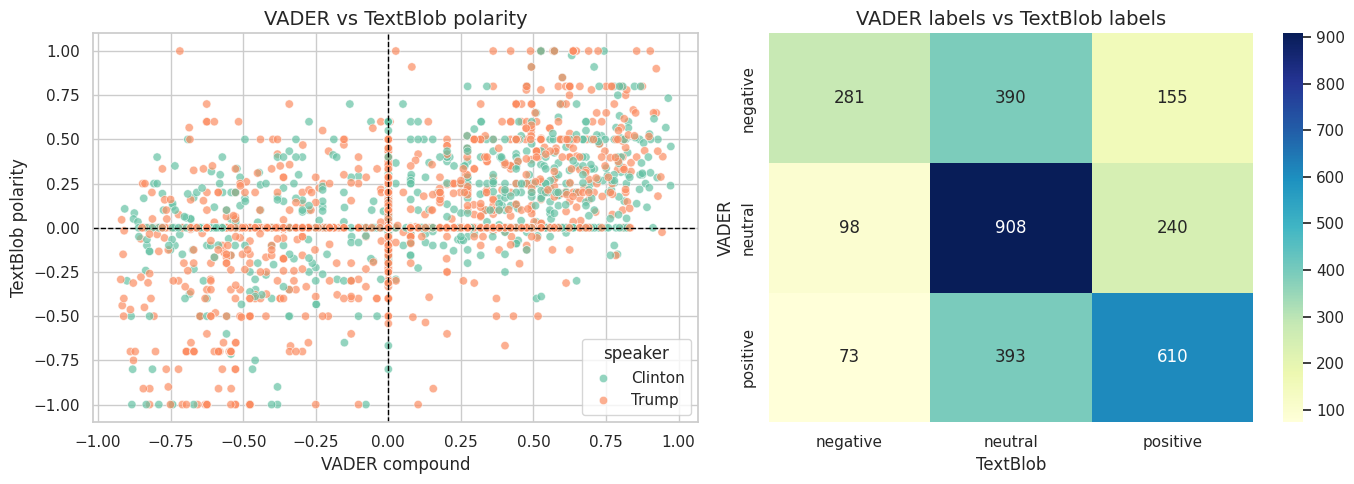

In [ ]:
if 'textblob_polarity' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.scatterplot(data=df, x='compound', y='textblob_polarity', hue='speaker', alpha=0.7, ax=axes[0])
    axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
    axes[0].axvline(0, color='black', linewidth=1, linestyle='--')
    axes[0].set_title('VADER vs TextBlob polarity')
    axes[0].set_xlabel('VADER compound')
    axes[0].set_ylabel('TextBlob polarity')

    comparison_counts = pd.crosstab(df['sentiment'], df['textblob_sentiment'])
    sns.heatmap(comparison_counts, annot=True, fmt='d', cmap='YlGnBu', ax=axes[1])
    axes[1].set_title('VADER labels vs TextBlob labels')
    axes[1].set_xlabel('TextBlob')
    axes[1].set_ylabel('VADER')

    plt.tight_layout()

    print('Correlation:', round(df[['compound', 'textblob_polarity']].corr().iloc[0, 1], 3))

In [ ]:

try:
    from transformers import pipeline

    transformer_sentiment = pipeline('sentiment-analysis')
    sample_for_transformer = df.sample(min(80, len(df)), random_state=42).copy()

    transformer_results = transformer_sentiment(
        sample_for_transformer['text'].str.slice(0, 512).tolist(),
        truncation=True
    )
    sample_for_transformer['transformer_label'] = [result['label'] for result in transformer_results]
    sample_for_transformer['transformer_score'] = [result['score'] for result in transformer_results]

    display(sample_for_transformer[['speaker', 'debate', 'sentiment', 'compound', 'transformer_label', 'transformer_score', 'text']].head(20))

    plt.figure(figsize=(10, 5))
    sns.countplot(data=sample_for_transformer, x='transformer_label', hue='speaker')
    plt.title('Transformer sentiment labels on a sentence sample')
    plt.xlabel('Transformer label')
    plt.ylabel('Sentence count')
    plt.tight_layout()
except ImportError:
    print('transformers is not installed. To try this section, run: %pip install transformers torch')
except Exception as exc:
    print('Transformer sentiment could not run:', exc)

transformers is not installed. To try this section, run: %pip install transformers torch
